In [13]:
%config InlineBackend.figure_format = 'svg'

import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import pathlib

_nb_file = globals().get('__vsc_ipynb_file__', '')
if _nb_file:
    os.chdir(pathlib.Path(_nb_file).resolve().parent)

project_root = str(pathlib.Path(os.getcwd()).parent)
sys.path.insert(0, project_root)

from src.utils import load_full_config
from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer

cfg = load_full_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
model = SimpleTransformer(**cfg['architecture']).to(device)
model_path = os.path.join('..', cfg['paths']['save_dir'], cfg['paths']['mgf_model_name'])
checkpoint = torch.load(model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded model from {model_path}')

Loaded model from ../experiments/model_mgf.pth


In [ ]:
# Generate a single trajectory
theta   = cfg['physics']['theta']
mu      = cfg['physics']['mu']
dt      = cfg['physics']['dt']
seq_len = cfg['structure']['sequence_length']
marginal_var = cfg['physics']['marginal_variance']

theta_t = torch.tensor([theta])
D_t     = marginal_var * theta_t
traj    = simulate_ou_process(1, seq_len, theta_t, mu, D_t, dt)  # (1, seq_len, 1)

with torch.no_grad():
    _, attn_maps = model(traj.to(device))

# attn_maps: list of (1, seq_len, seq_len) tensors, one per layer
print(f'Sequence length: {seq_len}')
print(f'Layers: {len(attn_maps)}, attention shape: {attn_maps[0].shape}')

Sequence length: 30
Layers: 2, attention shape: torch.Size([1, 30, 30])


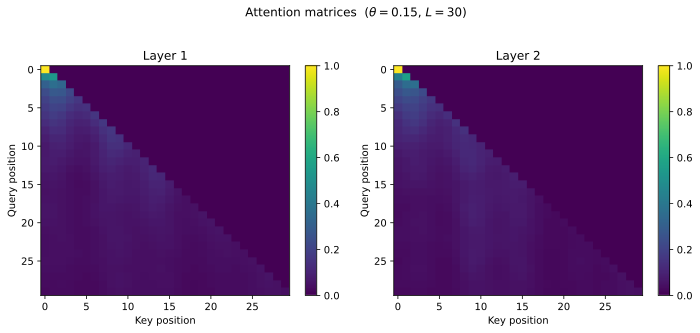

In [16]:
n_layers = len(attn_maps)
fig, axes = plt.subplots(1, n_layers, figsize=(5 * n_layers, 4.5))
if n_layers == 1:
    axes = [axes]

for i, (ax, attn) in enumerate(zip(axes, attn_maps)):
    mat = attn[0].cpu().numpy()  # (seq_len, seq_len)
    im = ax.imshow(mat, aspect='auto', origin='upper', cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'Layer {i + 1}')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')

plt.suptitle(rf'Attention matrices  ($\theta={theta}$, $L={seq_len}$)', y=1.02)
plt.tight_layout()
plt.show()